### Import Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

### Dataset Setup

In [2]:
dataset_path = r"F:\TERM 7\CSM422 (DEEP LEARNING)\Emotion_recognitition\notebooks\dataset"
### Classes 
### Angry, Disgust, Fear, Happy, Neutral, Sad, Surprise

### Data Loading and Splitting (80/20)
### We’ll use ImageDataGenerator to automatically split data and normalize it between 0 and 1.

In [3]:
img_size = (48, 48)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 31583 images belonging to 8 classes.
Found 7893 images belonging to 8 classes.


### Build CNN Model

In [4]:
# A clean, powerful CNN model for emotion detection.

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(48,48,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(train_gen.num_classes, activation='softmax')
])
model.summary()

C:\Users\kumar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Compile and Train

In [10]:
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30
)

Epoch 1/30
987/987 ━━━━━━━━━━━━━━━━━━━━ 129s 126ms/step - accuracy: 0.9088 - loss: 0.4996 - val_accuracy: 0.9093 - val_loss: 0.4824
Epoch 2/30
987/987 ━━━━━━━━━━━━━━━━━━━━ 120s 122ms/step - accuracy: 0.9089 - loss: 0.4779 - val_accuracy: 0.9093 - val_loss: 0.4849
Epoch 3/30
987/987 ━━━━━━━━━━━━━━━━━━━━ 124s 126ms/step - accuracy: 0.9086 - loss: 0.4637 - val_accuracy: 0.9093 - val_loss: 0.4864
Epoch 4/30
987/987 ━━━━━━━━━━━━━━━━━━━━ 537s 544ms/step - accuracy: 0.9086 - loss: 0.4438 - val_accuracy: 0.9093 - val_loss: 0.4795
Epoch 5/30
987/987 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - accuracy: 0.9074 - loss: 0.4269  


KeyboardInterrupt



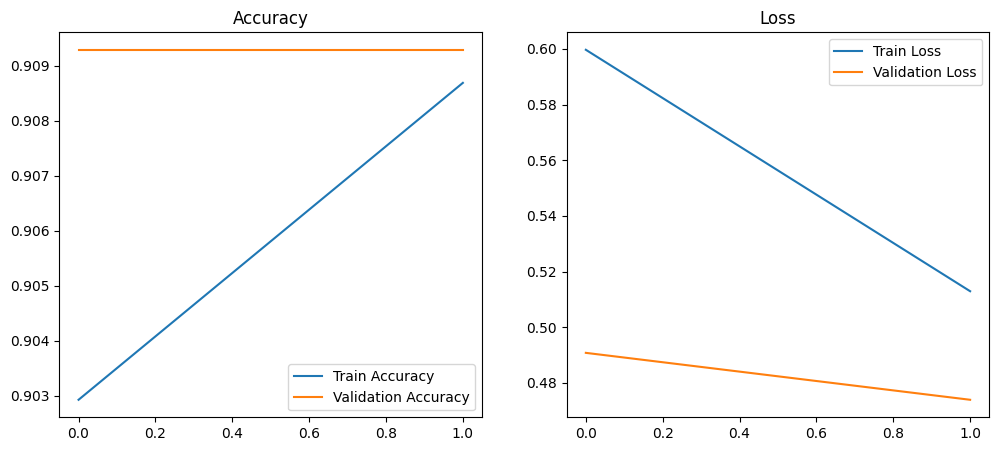

In [11]:
### Plot Accuracy & Loss

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')
plt.show()

In [ ]:
### Evaluation on Validation Data

val_gen.reset()
pred = model.predict(val_gen)
pred_classes = np.argmax(pred, axis=1)
true_classes = val_gen.classes
labels = list(val_gen.class_indices.keys())

print(classification_report(true_classes, pred_classes, target_names=labels))

 67/247 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step 

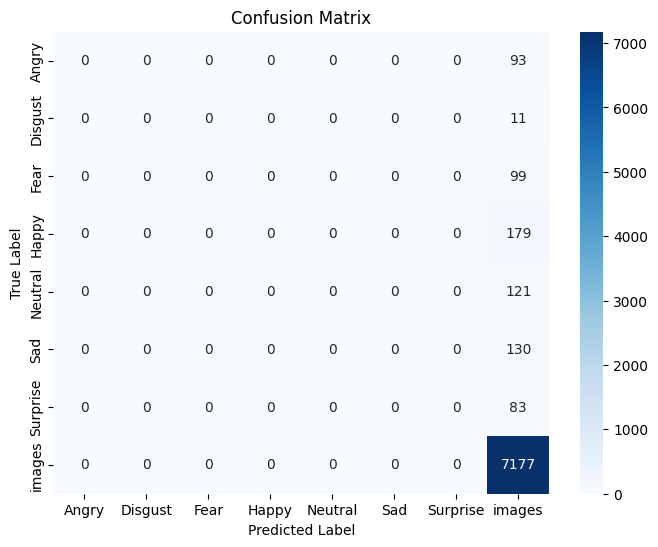

In [8]:
### Confusion Matrix

cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

###  Save the CNN Model

In [9]:
model.save("cnn_emotion_model.h5(2)")
print("Model saved as cnn_emotion_model.h5(2)")

Model saved as cnn_emotion_model.h5
